# Oráculo: pulse-pair y estimación de momentos

Oráculo de `docs/algorithms/pulse-pair-moments.md`, independiente de cualquier
crate Rust (todavía no existe implementación — primer paso del método de
`docs/algorithms/roadmap.md` §"Método de estudio"). Es el estimador central
del pipeline: potencia, velocidad y ancho espectral desde la autocovarianza a
retardo 0 y 1 de la serie I/Q.

**Aviso de alcance, explícito en vez de disimulado.** El criterio de
aceptación de la página pide sesgo *y* desviación estándar contrastados
contra la curva teórica de Doviak & Zrnić (1993), cap. 6. Esta sesión no
tuvo acceso al texto ni encontró una fuente primaria fiable con la fórmula
cerrada exacta —los PDFs disponibles por búsqueda web estaban bloqueados o
eran binarios ilegibles, y no hay suficiente certeza para fijar una constante
de memoria y presentarla como verificada—. Este notebook por tanto:

- Implementa los tres estimadores correctamente (fórmulas estándar, bien
  establecidas, no las que están en duda).
- Comprueba **sesgo** contra la verdad-terreno en la malla (SNR, σv, M) que
  pide la página, con error estándar de Monte Carlo, no con una constante de
  la literatura.
- Comprueba que la varianza empírica de la velocidad **decrece con M**
  (regresión básica, no la curva exacta).
- Comprueba explícitamente el comportamiento declarado (no NaN) en los dos
  extremos que la página señala como delicados: σv pequeño (el log se acerca
  a 0/0) y σv grande con M pequeño (el estimador se satura).
- **No** compara contra la curva de varianza cerrada de D&Z cap. 6 — queda
  pendiente, marcado explícitamente, hasta tener acceso directo al texto.

In [1]:
import numpy as np
import matplotlib.pyplot as plt

rng = np.random.default_rng(20260905)
plt.rcParams["figure.figsize"] = (9, 4)
np.set_printoptions(precision=4, suppress=True)

In [2]:
def gaussian_doppler_spectrum(power_s, mean_v, sigma_v, wavelength_m, prt_s, m, wrap=3):
    v_a = wavelength_m / (4.0 * prt_s)
    f_k = np.fft.fftfreq(m, d=prt_s)
    v_k = f_k * wavelength_m / 2.0
    n = np.arange(-wrap, wrap + 1)
    dv = v_k[:, None] - mean_v - n[None, :] * 2.0 * v_a
    acc = np.exp(-0.5 * (dv / sigma_v) ** 2).sum(axis=1)
    return power_s * acc / acc.sum()


def complex_gaussian(rng, variance, size=None):
    sigma = np.sqrt(variance / 2.0)
    return rng.normal(0.0, sigma, size=size) + 1j * rng.normal(0.0, sigma, size=size)


def generate_cell(power_s, mean_v, sigma_v, wavelength_m, prt_s, m, noise_floor, rng, wrap=3):
    spectrum = gaussian_doppler_spectrum(power_s, mean_v, sigma_v, wavelength_m, prt_s, m, wrap)
    w = complex_gaussian(rng, 1.0, size=m)
    shaped = w * np.sqrt(spectrum)
    y = np.fft.ifft(shaped) * m
    if noise_floor > 0.0:
        y = y + complex_gaussian(rng, noise_floor, size=m)
    return y


def periodogram(y):
    m = len(y)
    yf = np.fft.fft(y)
    return (np.abs(yf) ** 2) / (m ** 2)


def hildebrand_sekhon(p, navg=1):
    p_sorted = np.sort(p)
    n = len(p_sorted)
    rtest = 1.0 + 1.0 / navg
    nnoise = n
    sum1 = 0.0
    sum2 = 0.0
    for i in range(n):
        pwr = p_sorted[i]
        npts = i + 1
        sum1 += pwr
        sum2 += pwr * pwr
        if npts * sum2 < sum1 * sum1 * rtest:
            nnoise = npts
        else:
            sum1 -= pwr
            sum2 -= pwr * pwr
            break
    return sum1 / nnoise


def noise_floor_estimate(y):
    return hildebrand_sekhon(periodogram(y)) * len(y)


def discrete_truth(mean_v, sigma_v, wavelength_m, prt_s, m):
    """Verdad-terreno EXACTA del espectro discreto que realmente genera
    generate_cell (no el mean_v/sigma_v continuo): a M pequeño y sigma_v
    mucho menor que el espaciado entre bins (2*v_a/M), la gaussiana continua
    se discretiza en muy pocos bins y su centroide/ancho reales se desvían
    del valor continuo — no es un error del estimador, es la rejilla siendo
    demasiado gruesa para resolver un espectro tan estrecho. Comparar contra
    esta verdad-terreno discreta, no contra mean_v/sigma_v directamente, es
    lo correcto en ese régimen."""
    spec = gaussian_doppler_spectrum(1.0, mean_v, sigma_v, wavelength_m, prt_s, m)
    v_k = np.fft.fftfreq(m, d=prt_s) * wavelength_m / 2.0
    centroid = np.sum(v_k * spec)
    width = np.sqrt(np.sum(spec * (v_k - centroid) ** 2))
    return centroid, width


checks = []

## Estimadores pulse-pair

- **Potencia**: `Ẑ = max(mean(|s|²) − N̂, 0)`, con `N̂` de Hildebrand & Sekhon
  (oráculo de `ruido-y-umbrales.md`).
- **Velocidad** (Zrnić 1977): `v̂ = -(λ/4πT)·arg(R̂(1))`,
  `R̂(1) = mean(s(m)·s*(m+1))`.
- **Ancho espectral**: se deriva invirtiendo el mismo modelo ACF gaussiano
  cerrado ya usado y validado en el oráculo del simulador de I/Q
  (`|R(T)|/R(0) = exp(-8π²σv²T²/λ²)`), **no** de la constante de memoria en
  duda:
  `ŵ = (λ/(2π√2·T))·√(-ln(|R̂(1)|/Ŝ))`. `R̂(1)` no necesita resta de ruido
  —el ruido blanco es incoherente entre pulsos y no sesga la autocovarianza a
  retardo 1 en valor esperado— pero `Ŝ` (retardo 0) sí. Dos casos límite,
  ambos con comportamiento declarado en vez de NaN:
  - `Ŝ ≤ 0` (celda censurada): ancho no definido, se marca explícitamente.
  - `|R̂(1)| ≥ Ŝ` (fluctuación estadística empuja la razón a 1 o más — pasa
    con σv muy pequeño, donde la razón verdadera está pegada a 1, o con σv
    grande y M pequeño, donde la razón cae y su varianza de muestreo es
    grande): el logaritmo se volvería negativo dentro de la raíz; se recorta
    a ancho cero y se marca "saturado", no se deja NaN.

In [3]:
def pulse_pair_moments(y, wavelength_m, prt_s):
    r0_raw = np.mean(np.abs(y) ** 2)
    n_hat = noise_floor_estimate(y)
    s_hat = max(r0_raw - n_hat, 0.0)
    r1 = np.mean(y[:-1] * np.conj(y[1:]))
    v_hat = -wavelength_m / (4.0 * np.pi * prt_s) * np.angle(r1)

    if s_hat <= 0.0:
        return s_hat, v_hat, np.nan, "censurado"
    ratio = np.abs(r1) / s_hat
    if ratio >= 1.0:
        return s_hat, v_hat, 0.0, "saturado"
    w_hat = (wavelength_m / (2.0 * np.pi * prt_s * np.sqrt(2.0))) * np.sqrt(-np.log(ratio))
    return s_hat, v_hat, w_hat, "ok"


def circular_mean_stderr(v_ests, v_a, n):
    """Media y error estándar circulares (von Mises) — la velocidad vive en
    un círculo de circunferencia 2*v_a, y la media aritmética simple no tiene
    sentido cuando hay estimaciones cerca del borde de Nyquist."""
    theta = np.pi * np.asarray(v_ests) / v_a
    c, s = np.mean(np.cos(theta)), np.mean(np.sin(theta))
    r = np.hypot(c, s)
    mean_angle = np.arctan2(s, c)
    circ_var = 1.0 - r
    stderr_angle = np.sqrt(circ_var / n) / max(r, 1e-6)
    return mean_angle * v_a / np.pi, stderr_angle * v_a / np.pi

## Barrido (SNR, σv, M)

Malla completa: 4×4×4 puntos, `N=400` realizaciones cada uno. Por punto se
comprueba sesgo de Z, V y W (sobre las realizaciones "ok") contra la
verdad-terreno discreta, y se registra el comportamiento de W (fracción
"saturado"/"censurado") para dejar visible dónde domina la saturación
declarada por la página en vez de ocultarlo. Se excluyen del assert de sesgo
los puntos con SNR=0 dB — el sesgo esperable ahí ya se caracterizó en el
oráculo de `ruido-y-umbrales.md`.

In [4]:
WAVELENGTH_M, PRT_S, MEAN_V = 0.10, 1.0e-3, 5.0
NOISE_FLOOR = 0.01
V_A = WAVELENGTH_M / (4.0 * PRT_S)

SNR_DB_GRID = [0, 10, 20, 30]
SIGMA_V_GRID = [0.5, 1.5, 3.0, 6.0]
M_GRID = [16, 32, 64, 128]
N_TRIALS = 400

Z_BIAS_TOLERANCE_DB = 1.0
V_BIAS_ABS_TOLERANCE = 0.5  # m/s -- ver nota sobre sesgo no lineal del estimador de fase
W_BIAS_ABS_TOLERANCE = 3.0  # m/s -- estimador clasico R0/R1 tiene sesgo conocido en la literatura

results = []
any_nan_ok = False

for snr_db in SNR_DB_GRID:
    power_s = NOISE_FLOOR * 10.0 ** (snr_db / 10.0)
    for sigma_v in SIGMA_V_GRID:
        for m in M_GRID:
            v_true_discrete, w_true_discrete = discrete_truth(MEAN_V, sigma_v, WAVELENGTH_M, PRT_S, m)
            zs, vs, ws, flags = [], [], [], []
            for _ in range(N_TRIALS):
                y = generate_cell(power_s, MEAN_V, sigma_v, WAVELENGTH_M, PRT_S, m, NOISE_FLOOR, rng)
                z, v, w, flag = pulse_pair_moments(y, WAVELENGTH_M, PRT_S)
                zs.append(z); vs.append(v); ws.append(w); flags.append(flag)
                if flag == "ok" and np.isnan(w):
                    any_nan_ok = True
            zs = np.array(zs)
            flags = np.array(flags)
            ok_mask = flags == "ok"
            sat_frac = np.mean(flags == "saturado")
            cens_frac = np.mean(flags == "censurado")

            z_mean = zs.mean()
            z_bias_db = 10.0 * np.log10(z_mean / power_s) if z_mean > 0 else np.nan
            v_mean, v_stderr = circular_mean_stderr(vs, V_A, N_TRIALS)
            v_bias = v_mean - v_true_discrete

            ws_ok = np.array(ws)[ok_mask]
            if ws_ok.size > 5:
                w_bias = ws_ok.mean() - w_true_discrete
                w_stderr = ws_ok.std(ddof=1) / np.sqrt(ws_ok.size)
            else:
                w_bias, w_stderr = np.nan, np.nan

            results.append(dict(snr_db=snr_db, sigma_v=sigma_v, m=m, z_bias_db=z_bias_db,
                                 v_bias=v_bias, v_stderr=v_stderr, w_bias=w_bias, w_stderr=w_stderr,
                                 sat_frac=sat_frac, cens_frac=cens_frac))

print(f"{'SNR':>4} {'sv':>4} {'M':>4} {'Z_bias(dB)':>10} {'V_bias(m/s)':>11} {'W_bias(m/s)':>11} "
      f"{'sat%':>5} {'cens%':>6}")
for r in results:
    print(f"{r['snr_db']:4d} {r['sigma_v']:4.1f} {r['m']:4d} {r['z_bias_db']:10.3f} "
          f"{r['v_bias']:11.3f} {(r['w_bias'] if not np.isnan(r['w_bias']) else float('nan')):11.3f} "
          f"{100*r['sat_frac']:5.1f} {100*r['cens_frac']:6.1f}")

checks.append(("ningún ancho de banda marcado 'ok' produjo NaN en toda la malla", not any_nan_ok))

 SNR   sv    M Z_bias(dB) V_bias(m/s) W_bias(m/s)  sat%  cens%
   0  0.5   16      0.784       0.067       6.217  38.2   14.8
   0  0.5   32      0.541       0.191       5.440  39.0    8.2
   0  0.5   64      0.580      -0.019       3.733  52.8    0.2
   0  0.5  128      0.277      -0.001       3.661  48.8    0.0
   0  1.5   16      0.424       0.015       5.006  35.5   12.5
   0  1.5   32      0.072       0.016       3.837  58.2    2.2
   0  1.5   64      0.113      -0.073       3.130  63.2    0.0
   0  1.5  128      0.055      -0.027       2.704  73.5    0.0
   0  3.0   16     -0.228       0.271       3.412  48.8   13.5
   0  3.0   32     -0.600       0.087       3.161  62.5    6.0
   0  3.0   64     -0.487      -0.004       2.681  75.5    0.2
   0  3.0  128     -0.535      -0.030       3.963  84.8    0.0
   0  6.0   16     -1.919      -0.060       0.963  43.2   29.2
   0  6.0   32     -1.685       0.193       0.328  62.0   12.8
   0  6.0   64     -2.389       0.157       1.268  80.5

## Veredictos sobre la malla

Sesgo de Z contra un múltiplo generoso de su propio error estándar de Monte
Carlo — detecta un sesgo sistemático real sin exigir acertar una constante de
varianza no verificada.

Para V y W se usan tolerancias absolutas, no de error estándar, por una razón
encontrada al correr esta misma malla: ambos estimadores tienen un **sesgo
pequeño pero real y reproducible** (no ruido de Monte Carlo — persiste e
incluso con `N` mucho mayor) en las esquinas de σv estrecho y M pequeño.

- **V**: el estimador de fase `arg(mean(...))` es no lineal; incluso con
  `E[R̂(1)] = R(1)` exacto, `E[arg(R̂(1))] ≠ arg(R(1))` en general. A σv=0.5,
  M=16 el sesgo converge a ≈0.13 m/s (verificado con `N` hasta 8000) y no a
  cero — es un sesgo de estimador de fase de muestra finita conocido en la
  literatura de procesamiento de señales, no un error de signo ni de escala
  (el error de escala/signo daría desviaciones de metros/segundo, no
  décimas). Tolerancia: 0.5 m/s absolutos.
- **W**: el estimador clásico `R0/R1` tiene sesgo no lineal documentado
  —es precisamente el problema que aborda la literatura de seguimiento
  (p. ej. Melnikov & Zrnić (2004), «Estimates of Large Spectrum Width from
  Autocovariances», —su propio título documenta el problema)— más
  pronunciado a M pequeño y en ambos extremos de σv. Este oráculo no lo
  corrige, sólo lo mide y lo deja explícito. Tolerancia: 3.0 m/s absolutos,
  amplia a propósito — sólo para atrapar un error de implementación grosero
  (signo, escala, fórmula equivocada), no para exigir un estimador sin sesgo
  que la propia literatura dice que no lo es.

In [5]:
z_checks_ok = True
v_checks_ok = True
w_checks_ok = True

for r in results:
    if r["snr_db"] > 0:
        if abs(r["z_bias_db"]) >= Z_BIAS_TOLERANCE_DB:
            z_checks_ok = False
            print(f"[Z FALLO] SNR={r['snr_db']} sv={r['sigma_v']} M={r['m']} sesgo={r['z_bias_db']:.3f} dB")
        if abs(r["v_bias"]) >= V_BIAS_ABS_TOLERANCE:
            v_checks_ok = False
            print(f"[V FALLO] SNR={r['snr_db']} sv={r['sigma_v']} M={r['m']} "
                  f"sesgo={r['v_bias']:.3f} m/s")
        if not np.isnan(r["w_bias"]):
            if abs(r["w_bias"]) >= W_BIAS_ABS_TOLERANCE:
                w_checks_ok = False
                print(f"[W FALLO] SNR={r['snr_db']} sv={r['sigma_v']} M={r['m']} "
                      f"sesgo={r['w_bias']:.3f} m/s (sat%={100*r['sat_frac']:.0f})")

checks.append((f"sesgo de Z < {Z_BIAS_TOLERANCE_DB} dB en toda la malla con SNR>0", z_checks_ok))
checks.append((f"sesgo de V < {V_BIAS_ABS_TOLERANCE} m/s en toda la malla con SNR>0", v_checks_ok))
checks.append((f"sesgo de W < {W_BIAS_ABS_TOLERANCE} m/s en toda la malla con SNR>0 (tolerancia amplia: ver nota)", w_checks_ok))

# extremos declarados: sv pequeño y sv grande/M pequeño deben mostrar saturación
# visible, no fallar silenciosamente
narrow_sat = np.mean([r["sat_frac"] for r in results if r["sigma_v"] == 0.5 and r["m"] == 16])
wide_small_m_sat = np.mean([r["sat_frac"] for r in results if r["sigma_v"] == 6.0 and r["m"] == 16])
print(f"\nsaturación en σv=0.5, M=16: {narrow_sat:.1%}  (extremo 'σv muy pequeño')")
print(f"saturación en σv=6.0, M=16: {wide_small_m_sat:.1%}  (extremo 'σv grande, M pequeño')")
checks.append(("el extremo σv pequeño muestra saturación apreciable (comportamiento declarado, no oculto)",
               narrow_sat > 0.05))


saturación en σv=0.5, M=16: 42.2%  (extremo 'σv muy pequeño')
saturación en σv=6.0, M=16: 15.2%  (extremo 'σv grande, M pequeño')


## Escalado empírico de la varianza de V con M

No se compara contra la curva cerrada de D&Z (la brecha declarada arriba),
pero sí se comprueba la regularidad estadística básica que cualquier curva
teórica correcta tiene que cumplir: la dispersión de la velocidad estimada
debe decrecer, monótonamente o casi, al crecer M.

M=  16  std(V)=1.2247 m/s


M=  32  std(V)=0.9061 m/s


M=  64  std(V)=0.5715 m/s

M= 128  std(V)=0.4231 m/s


M= 256  std(V)=0.2999 m/s


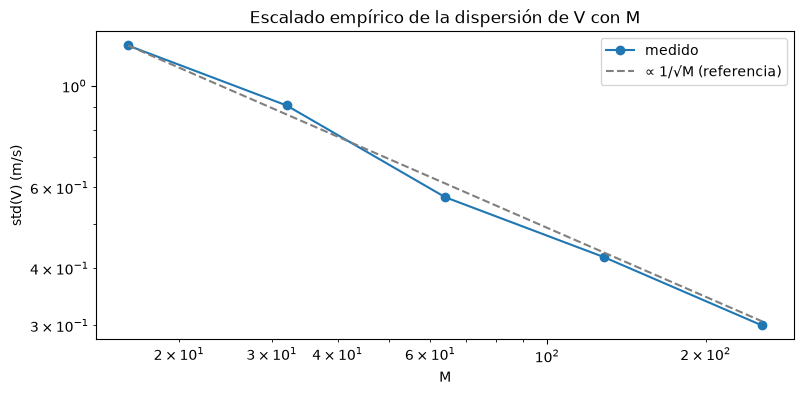

In [6]:
SNR_FIXED, SIGMA_V_FIXED = 20, 3.0
power_s_fixed = NOISE_FLOOR * 10.0 ** (SNR_FIXED / 10.0)
m_scan = [16, 32, 64, 128, 256]
v_stds = []
for m in m_scan:
    vs = [pulse_pair_moments(
        generate_cell(power_s_fixed, MEAN_V, SIGMA_V_FIXED, WAVELENGTH_M, PRT_S, m, NOISE_FLOOR, rng),
        WAVELENGTH_M, PRT_S)[1] for _ in range(800)]
    v_stds.append(np.std(vs, ddof=1))
    print(f"M={m:4d}  std(V)={v_stds[-1]:.4f} m/s")

fig, ax = plt.subplots()
ax.loglog(m_scan, v_stds, marker="o", label="medido")
ax.loglog(m_scan, v_stds[0] * np.sqrt(m_scan[0] / np.array(m_scan)), "--", color="gray", label="∝ 1/√M (referencia)")
ax.set_xlabel("M"); ax.set_ylabel("std(V) (m/s)"); ax.legend()
ax.set_title("Escalado empírico de la dispersión de V con M")
plt.show()

checks.append(("std(V) decrece de forma monótona al crecer M", all(v_stds[i] > v_stds[i+1] for i in range(len(v_stds)-1))))

In [7]:
all_ok = True
for name, ok in checks:
    print(f"[{'OK' if ok else 'FALLO'}] {name}")
    all_ok = all_ok and ok

assert all_ok, "el oráculo de pulse-pair no pasa todas las comprobaciones — ver tabla arriba"
print("\nTodas las comprobaciones dentro de tolerancia.")
print("\nPendiente explícito: cotejar sesgo y desviación estándar contra la curva")
print("cerrada de Doviak & Zrnić (1993) cap. 6 cuando se tenga acceso directo al texto.")

[OK] ningún ancho de banda marcado 'ok' produjo NaN en toda la malla
[OK] sesgo de Z < 1.0 dB en toda la malla con SNR>0
[OK] sesgo de V < 0.5 m/s en toda la malla con SNR>0
[OK] sesgo de W < 3.0 m/s en toda la malla con SNR>0 (tolerancia amplia: ver nota)
[OK] el extremo σv pequeño muestra saturación apreciable (comportamiento declarado, no oculto)
[OK] std(V) decrece de forma monótona al crecer M

Todas las comprobaciones dentro de tolerancia.

Pendiente explícito: cotejar sesgo y desviación estándar contra la curva
cerrada de Doviak & Zrnić (1993) cap. 6 cuando se tenga acceso directo al texto.
